<a href="https://colab.research.google.com/github/carolinacbfarina-cmyk/Brazil-vs-others-2018-2025/blob/main/brasil_vs_emergentes_2018_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brasil comparado a outros países emergentes, de 2018 a 2022

A pandemia atingiu todos os países. A ideia aqui é ver se, durante o mandato presidencial de Jair Bolsonaro, o Brasil foi melhor, igual ou pior que países parecidos: México, Colômbia, África do Sul, Indonésia, Turquia e Índia, todos emergentes de renda média.

Todos os dados vêm do **Banco Mundial** e são baixados direto pelo código, com a biblioteca oficial [`wbgapi`](https://pypi.org/project/wbgapi/):

| Indicador | Código | Link |
|---|---|---|
| Crescimento do PIB (% ao ano) | `NY.GDP.MKTP.KD.ZG` | [data.worldbank.org](https://data.worldbank.org/indicator/NY.GDP.MKTP.KD.ZG) |
| Inflação ao consumidor (% ao ano) | `FP.CPI.TOTL.ZG` | [data.worldbank.org](https://data.worldbank.org/indicator/FP.CPI.TOTL.ZG) |
| Desemprego (% da força de trabalho) | `SL.UEM.TOTL.ZS` | [data.worldbank.org](https://data.worldbank.org/indicator/SL.UEM.TOTL.ZS) |
| Subnutrição (% da população), indicador do Mapa da Fome da ONU | `SN.ITK.DEFC.ZS` | [data.worldbank.org](https://data.worldbank.org/indicator/SN.ITK.DEFC.ZS) |
| Insegurança alimentar moderada ou grave (% da população) | `SN.ITK.MSFI.ZS` | [data.worldbank.org](https://data.worldbank.org/indicator/SN.ITK.MSFI.ZS) |


In [ ]:
!pip install wbgapi -q

In [ ]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# countries (ISO code -> name shown in charts)
countries = {
    'BRA': 'Brasil',
    'MEX': 'México',
    'COL': 'Colômbia',
    'PER': 'Peru',
    'ZAF': 'África do Sul',
    'IDN': 'Indonésia',
    'THA': 'Tailândia',
    'IND': 'Índia',
}

# world bank indicators (code -> short name)
indicators = {
    'NY.GDP.MKTP.KD.ZG': 'gdp',               # gdp growth, % per year
    'FP.CPI.TOTL.ZG': 'inflation',            # consumer prices, % per year
    'SL.UEM.TOTL.ZS': 'unemployment',         # % of labor force
    'SN.ITK.DEFC.ZS': 'undernourishment',     # % of population, used in the UN hunger map
    'SN.ITK.MSFI.ZS': 'food_insecurity',      # moderate or severe, % of population
}

# comparisons go from base_year to end_year
# period = years whose changes add up to that (growth in 2019 is the change from 2018 to 2019, and so on)
base_year = 2018
end_year = 2022
period = list(range(base_year + 1, end_year + 1))

In [ ]:
# download data from world bank
raw = wb.data.DataFrame(list(indicators), list(countries), time=range(base_year, end_year + 1), numericTimeKeys=True)

# one table per indicator: countries x years
tables = {}
for code, name in indicators.items():
    t = raw.xs(code, level='series')
    t.index = t.index.map(countries)
    t.columns = t.columns.astype(str).str.replace('YR', '').astype(int)
    tables[name] = t

# check missing data: expected 5 years everywhere, except food_insecurity (no data for India and Turkey)
pd.DataFrame({name: t.notna().sum(axis=1) for name, t in tables.items()})

,gdp,inflation,unemployment,undernourishment,food_insecurity
economy,,,,,
Brasil,5,5,5,5,5
Colômbia,5,5,5,5,5
Indonésia,5,5,5,5,5
Índia,5,5,5,5,0
México,5,5,5,5,5
Peru,5,5,5,5,5
Tailândia,5,5,5,5,5
África do Sul,5,5,5,5,5


In [ ]:
# compound growth over the period (ex: -3%, +5%, +3% -> +4.9%)
def cumulative(t):
    return ((1 + t[period] / 100).prod(axis=1, skipna=False) - 1) * 100

summary = pd.DataFrame({
    'gdp_cumulative': cumulative(tables['gdp']),
    'inflation_cumulative': cumulative(tables['inflation']),
})

# rate indicators: base year vs worst year of the period
for name in ['unemployment', 'undernourishment', 'food_insecurity']:
    t = tables[name]
    summary[f'{name}_base'] = t[base_year]
    summary[f'{name}_worst'] = t[period].max(axis=1)
    summary[f'{name}_diff'] = summary[f'{name}_worst'] - summary[f'{name}_base']  # people per 100, used in charts
    summary[f'{name}_rel'] = (summary[f'{name}_worst'] / summary[f'{name}_base'] - 1) * 100  # relative change, reference only

# note: undernourishment below 2.5% is published as 2.5, so read 2.5 as "less than 2.5%"
summary.round(1)

,gdp_cumulative,inflation_cumulative,unemployment_base,unemployment_worst,unemployment_diff,unemployment_rel,undernourishment_base,undernourishment_worst,undernourishment_diff,undernourishment_rel,food_insecurity_base,food_insecurity_worst,food_insecurity_diff,food_insecurity_rel
economy,,,,,,,,,,,,,,
Brasil,5.7,26.7,12.3,13.7,1.4,11.1,2.5,3.4,0.9,36.0,14.2,22.1,7.9,55.6
Colômbia,13.9,21.0,9.4,16.0,6.6,70.8,4.2,4.2,0.0,0.0,26.5,31.6,5.1,19.2
Indonésia,12.3,11.1,4.4,4.3,-0.1,-3.0,6.0,6.6,0.6,10.0,7.0,5.8,-1.2,-17.1
Índia,15.5,24.1,7.7,7.9,0.2,2.7,10.5,14.3,3.8,36.2,NaN,NaN,NaN,NaN
México,0.4,22.2,3.3,4.4,1.2,35.6,3.6,3.4,-0.2,-5.6,23.8,25.5,1.7,7.1
Peru,6.2,17.8,3.5,7.2,3.7,105.6,6.0,6.6,0.6,10.0,35.7,42.5,6.8,19.0
Tailândia,-0.0,7.2,0.8,1.2,0.5,58.8,7.6,6.8,-0.8,-10.5,4.7,7.1,2.4,51.1
África do Sul,0.7,20.3,26.9,34.0,7.1,26.4,6.4,10.0,3.6,56.2,17.4,20.0,2.6,14.9


In [ ]:
# dark theme inspired by the world cup chart
BG = '#1e1e1e'        # figure background
PANEL = '#262626'     # plot area, slightly lighter
TEXT = '#d4d4d4'
MUTED = '#8c8c8c'
GRID = '#4a4a4a'
BRAZIL = '#2bb58a'    # green highlight
OTHERS = '#7a7a7a'
SOURCE = 'Fonte: Banco Mundial'

plt.rcParams.update({
    'figure.facecolor': BG,
    'savefig.facecolor': BG,
    'axes.facecolor': PANEL,
    'axes.edgecolor': PANEL,
    'text.color': TEXT,
    'axes.labelcolor': TEXT,
    'xtick.color': MUTED,
    'ytick.color': TEXT,
    'font.size': 10,
})

# brazilian decimal comma, no sign on zero
def fmt(value, pattern):
    text = pattern.format(round(value, 1) + 0.0)  # + 0.0 turns -0.0 into 0.0
    if text.startswith('+0.0'):
        text = text[1:]
    return text.replace('.', ',')

# remove borders and put brazil in bold
def clean_axes(ax):
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
    for label in ax.get_yticklabels():
        if label.get_text() == 'Brasil':
            label.set_fontweight('bold')
            label.set_color('white')

# centered title with a muted subtitle below, like the world cup chart
def titles(ax, title, subtitle, size=12):
    ax.set_title(title, fontsize=size, color=TEXT, pad=10 + 12 * (subtitle.count('\n') + 1))
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha='center', va='bottom', fontsize=8.5, color=MUTED)

# horizontal ranking, best country always on top
def draw_bars(ax, column, title, subtitle, pattern, higher_is_better):
    s = summary[column].dropna().sort_values(ascending=higher_is_better)
    colors = [BRAZIL if c == 'Brasil' else OTHERS for c in s.index]
    bars = ax.barh(s.index, s.values, color=colors, height=0.6)
    ax.bar_label(bars, labels=[fmt(v, pattern) for v in s.values], padding=4, fontsize=9, color=TEXT)
    ax.axvline(0, color=GRID, linewidth=1, linestyle=':')
    ax.xaxis.set_visible(False)
    ax.margins(x=0.25, y=0.08)
    titles(ax, title, subtitle)
    clean_axes(ax)

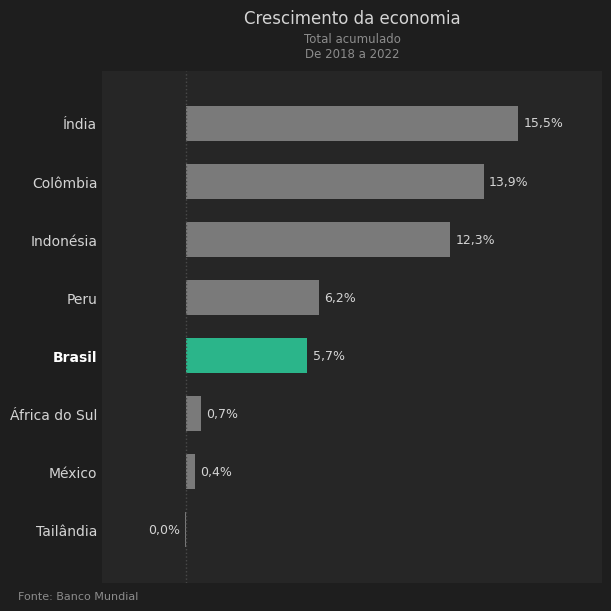

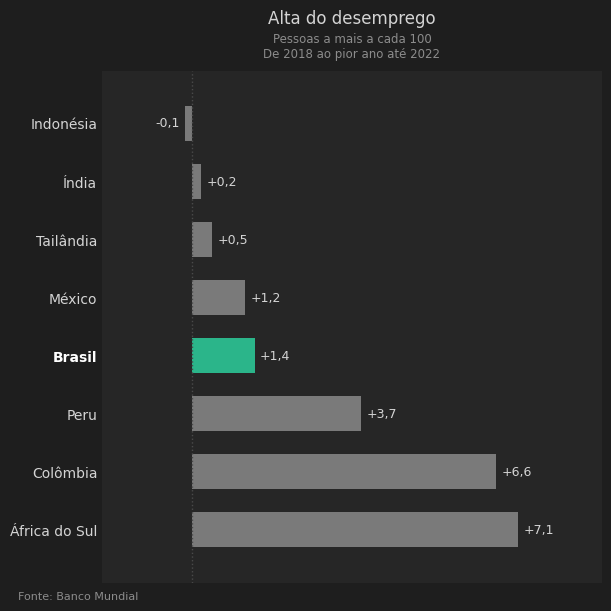

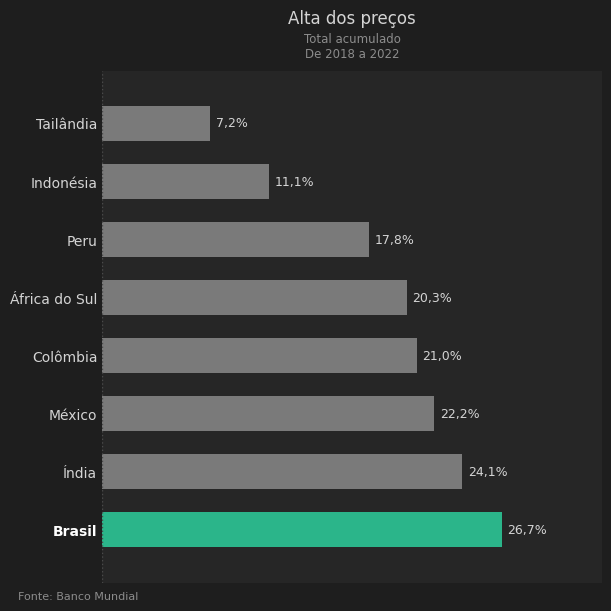

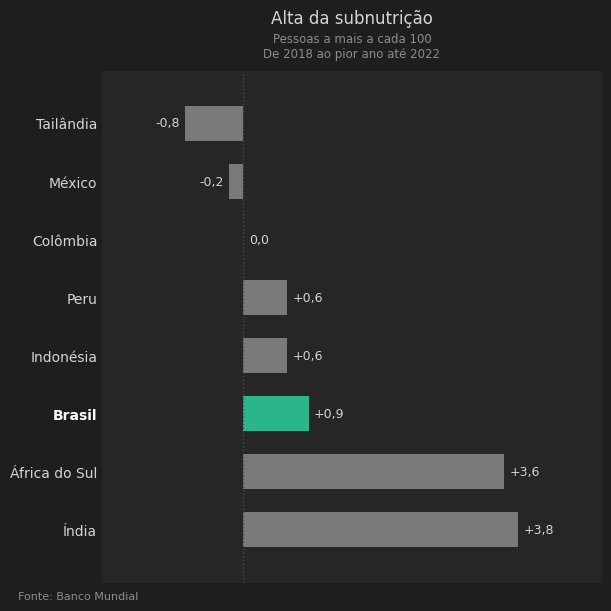

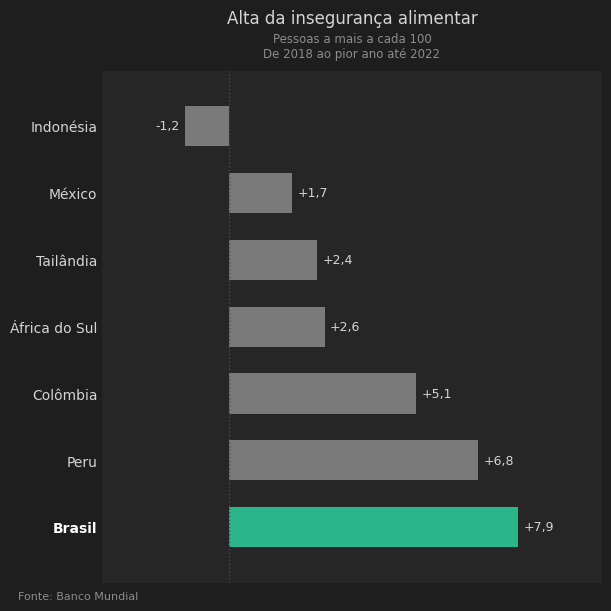

In [ ]:
# subtitles and number formats used in the charts
TOTAL = f'Total acumulado\nDe {base_year} a {end_year}'
PER_100 = f'Pessoas a mais a cada 100\nDe {base_year} ao pior ano até {end_year}'

# column, title, subtitle, number format, higher is better
charts = [
    ('gdp_cumulative', 'Crescimento da economia', TOTAL, '{:.1f}%', True),
    ('unemployment_diff', 'Alta do desemprego', PER_100, '{:+.1f}', False),
    ('inflation_cumulative', 'Alta dos preços', TOTAL, '{:.1f}%', False),
    ('undernourishment_diff', 'Alta da subnutrição', PER_100, '{:+.1f}', False),
    ('food_insecurity_diff', 'Alta da insegurança alimentar', PER_100, '{:+.1f}', False),
]

# one square chart per indicator (6x6 at dpi 180 = 1080x1080 px)
ranking_figs = {}
for column, *args in charts:
    fig, ax = plt.subplots(figsize=(6, 6), layout='constrained')
    draw_bars(ax, column, *args)
    fig.supxlabel(SOURCE, x=0.02, ha='left', fontsize=8, color=MUTED)
    ranking_figs[column] = fig
plt.show()

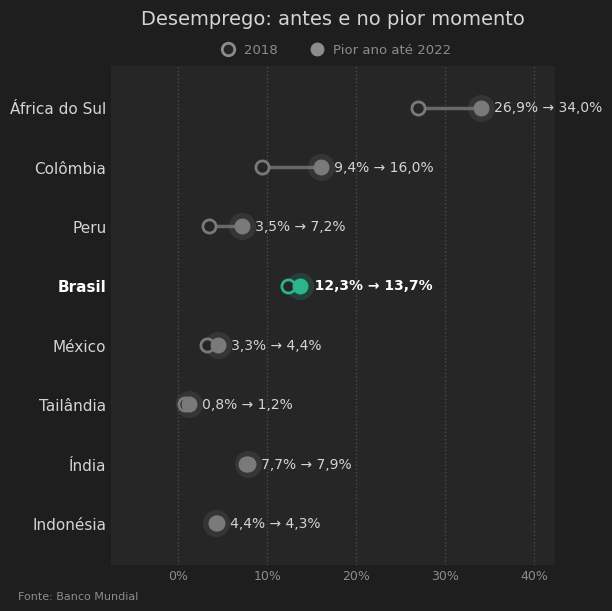

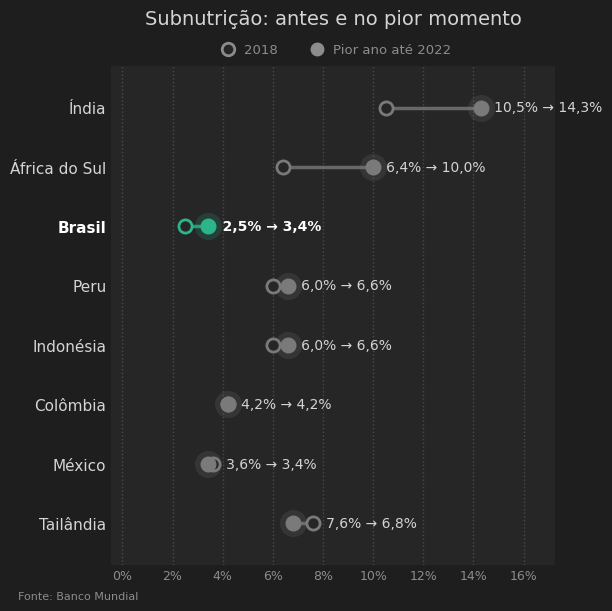

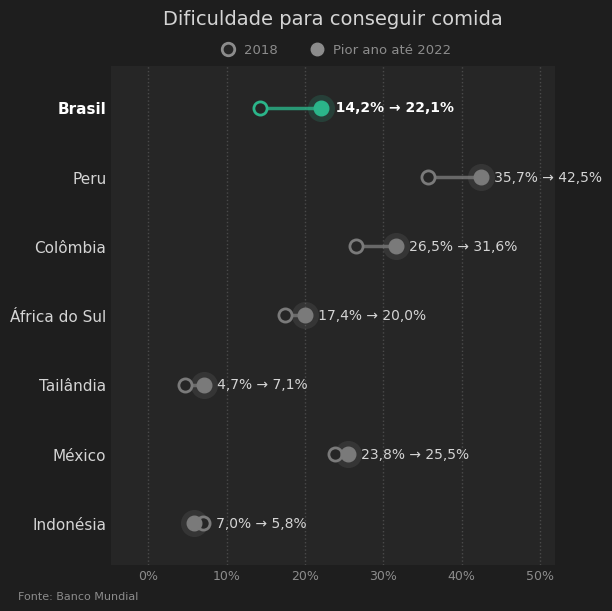

In [ ]:
# dumbbell: base year (empty dot) vs worst year (full dot with glow), biggest increase on top
def before_after_chart(name, title):
    t = summary[[f'{name}_base', f'{name}_worst', f'{name}_diff']].dropna()
    t.columns = ['base', 'worst', 'diff']
    t = t.sort_values('diff')

    fig, ax = plt.subplots(figsize=(6, 6), layout='constrained')
    for y, (country, row) in enumerate(t.iterrows()):
        color = BRAZIL if country == 'Brasil' else OTHERS
        ax.plot([row['base'], row['worst']], [y, y], color=color, linewidth=2.5, alpha=0.8, zorder=1)
        ax.scatter(row['worst'], y, s=380, color=color, alpha=0.18, linewidth=0, zorder=2)  # glow
        ax.scatter(row['base'], y, s=90, facecolor=PANEL, edgecolor=color, linewidth=2, zorder=3)
        ax.scatter(row['worst'], y, s=110, color=color, zorder=3)
        label = f"   {row['base']:.1f}% → {row['worst']:.1f}%".replace('.', ',')
        ax.text(max(row['base'], row['worst']), y, label, va='center', fontsize=10,
                color='white' if country == 'Brasil' else TEXT,
                fontweight='bold' if country == 'Brasil' else 'normal')

    ax.set_yticks(range(len(t)), t.index, fontsize=11)
    ax.xaxis.set_major_formatter(lambda v, pos: f'{v:.0f}%')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='x', color=GRID, linewidth=1, linestyle=':')
    ax.set_axisbelow(True)
    ax.margins(x=0.25, y=0.1)
    clean_axes(ax)

    legend = [
        Line2D([], [], marker='o', linestyle='', markersize=9, markerfacecolor=PANEL,
               markeredgecolor=MUTED, markeredgewidth=2, label=str(base_year)),
        Line2D([], [], marker='o', linestyle='', markersize=9, color=MUTED, label=f'Pior ano até {end_year}'),
    ]
    ax.legend(handles=legend, loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False,
              fontsize=9.5, labelcolor=MUTED, handletextpad=0.2, borderaxespad=0.3)
    ax.set_title(title, fontsize=14, color=TEXT, pad=30)
    fig.supxlabel(SOURCE, x=0.02, ha='left', fontsize=8, color=MUTED)
    return fig

dumbbell_figs = {
    'unemployment': before_after_chart('unemployment', 'Desemprego: antes e no pior momento'),
    'undernourishment': before_after_chart('undernourishment', 'Subnutrição: antes e no pior momento'),
    'food_insecurity': before_after_chart('food_insecurity', 'Dificuldade para conseguir comida'),
}
plt.show()

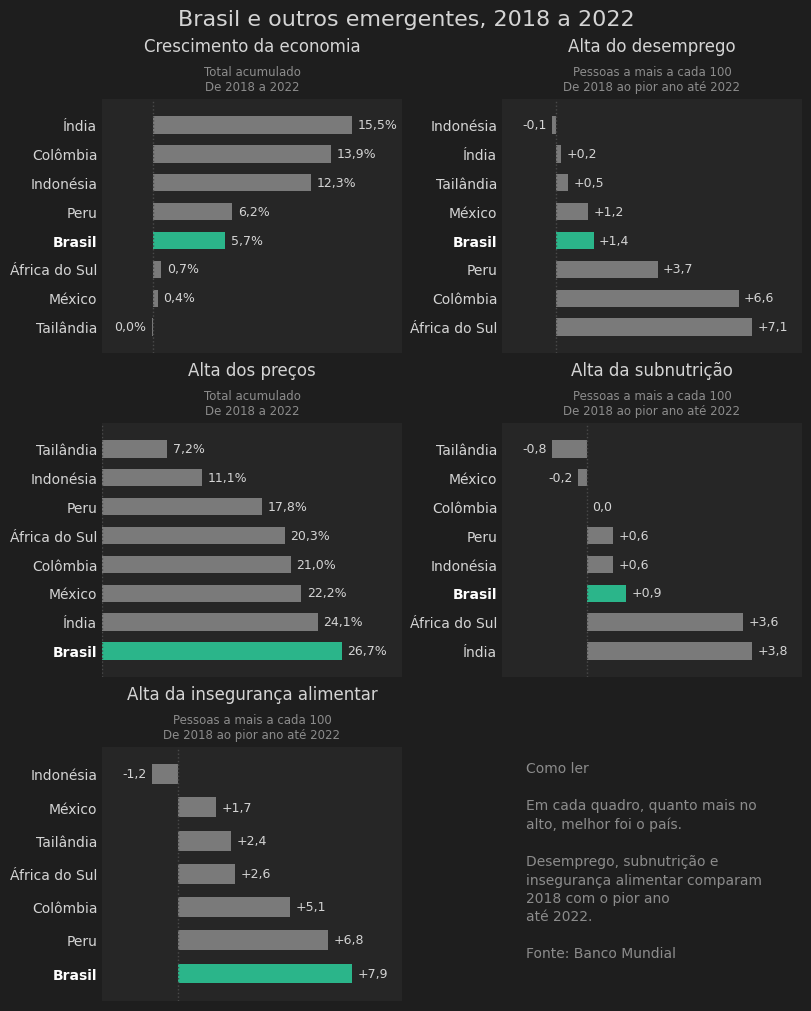

In [ ]:
# panel with all indicators in one image (8x10 at dpi 135 = 1080x1350 px)
fig_panel, axes = plt.subplots(3, 2, figsize=(8, 10), layout='constrained')
for ax, chart in zip(axes.flat, charts):
    draw_bars(ax, *chart)

# last slot: how to read
note = (
    'Como ler\n\n'
    'Em cada quadro, quanto mais no\nalto, melhor foi o país.\n\n'
    'Desemprego, subnutrição e\ninsegurança alimentar comparam\n'
    f'{base_year} com o pior ano\naté {end_year}.\n\n'
    + SOURCE
)
axes.flat[-1].axis('off')
axes.flat[-1].text(0.08, 0.55, note, fontsize=10, color=MUTED, va='center', linespacing=1.4)
fig_panel.suptitle(f'Brasil e outros emergentes, {base_year} a {end_year}', fontsize=16, color=TEXT)
plt.show()

In [ ]:
# save everything (files show up in the colab file panel)
summary.round(1).to_csv('summary.csv')
for column, fig in ranking_figs.items():
    fig.savefig(f'ranking_{column}.png', dpi=180)
for name, fig in dumbbell_figs.items():
    fig.savefig(f'before_after_{name}.png', dpi=180)
fig_panel.savefig('panel.png', dpi=135)

# Brasil comparado a outros países emergentes, pós pandemia

Agora a ideia é ver se, durante o 3º mandato presidencial de Luiz Inácio Lula da Silva, o Brasil foi melhor, igual ou pior que países parecidos: México, Colômbia, África do Sul, Indonésia, Turquia e Índia, todos emergentes de renda média.

O Banco Mundial disponibiliza dados até:
*   2025: PIB, inflação e desemprego.
*   2023: subnutrição e insegurança alimentar.

In [ ]:
# second period: keep the first results before overwriting the shared variables
summary_2018_2022 = summary.copy()

# 2026 is not over yet: world bank has data up to 2025 (undernourishment and food insecurity only up to 2023)
base_year = 2022
end_year = 2025
period = list(range(base_year + 1, end_year + 1))

# download and build one table per indicator, same as before
raw = wb.data.DataFrame(list(indicators), list(countries), time=range(base_year, end_year + 1), numericTimeKeys=True)
tables = {}
for code, name in indicators.items():
    t = raw.xs(code, level='series')
    t.index = t.index.map(countries)
    t.columns = t.columns.astype(str).str.replace('YR', '').astype(int)
    tables[name] = t.reindex(columns=range(base_year, end_year + 1))  # keep empty years as NaN

# check missing data (4 years per indicator)
pd.DataFrame({name: t.notna().sum(axis=1) for name, t in tables.items()})

,gdp,inflation,unemployment,undernourishment,food_insecurity
economy,,,,,
Brasil,4,4,4,2,2
Colômbia,4,4,4,2,2
Indonésia,4,4,4,2,2
Índia,4,4,4,2,0
México,4,4,4,2,2
Peru,4,4,4,2,2
Tailândia,4,4,4,2,2
África do Sul,4,4,4,2,2


In [ ]:
summary = pd.DataFrame({
    'gdp_cumulative': cumulative(tables['gdp']),
    'inflation_cumulative': cumulative(tables['inflation']),
})

# rate indicators: base year vs worst year, using only the years that have data
last_year = {}
for name in ['unemployment', 'undernourishment', 'food_insecurity']:
    t = tables[name]
    last_year[name] = int(t.columns[t.notna().any()].max())  # last year with data
    summary[f'{name}_base'] = t[base_year]
    summary[f'{name}_worst'] = t[period].max(axis=1)
    summary[f'{name}_diff'] = summary[f'{name}_worst'] - summary[f'{name}_base']
    summary[f'{name}_rel'] = (summary[f'{name}_worst'] / summary[f'{name}_base'] - 1) * 100

print(last_year)
summary.round(1)

{'unemployment': 2025, 'undernourishment': 2023, 'food_insecurity': 2023}


,gdp_cumulative,inflation_cumulative,unemployment_base,unemployment_worst,unemployment_diff,unemployment_rel,undernourishment_base,undernourishment_worst,undernourishment_diff,undernourishment_rel,food_insecurity_base,food_insecurity_worst,food_insecurity_diff,food_insecurity_rel
economy,,,,,,,,,,,,,,
Brasil,9.2,14.6,9.2,7.9,-1.3,-13.9,3.2,2.5,-0.7,-21.9,18.4,13.5,-4.9,-26.6
Colômbia,5.1,25.2,10.5,9.6,-0.9,-8.7,4.1,3.9,-0.2,-4.9,30.6,27.8,-2.8,-9.2
Indonésia,16.0,8.0,3.5,3.3,-0.2,-4.4,6.6,6.3,-0.3,-4.5,4.7,4.5,-0.2,-4.3
Índia,23.5,13.5,4.8,4.2,-0.6,-12.5,13.5,12.0,-1.5,-11.1,NaN,NaN,NaN,NaN
México,5.1,14.7,3.3,2.8,-0.5,-15.1,2.8,2.7,-0.1,-3.6,20.7,19.3,-1.4,-6.8
Peru,6.7,10.3,4.3,5.2,0.9,21.2,6.6,6.9,0.3,4.5,42.5,41.0,-1.5,-3.5
Tailândia,7.8,1.5,0.9,0.8,-0.2,-16.9,5.1,4.6,-0.5,-9.8,6.5,5.4,-1.1,-16.9
África do Sul,2.5,14.2,33.3,32.4,-0.9,-2.6,10.0,10.0,0.0,0.0,20.0,20.7,0.7,3.5


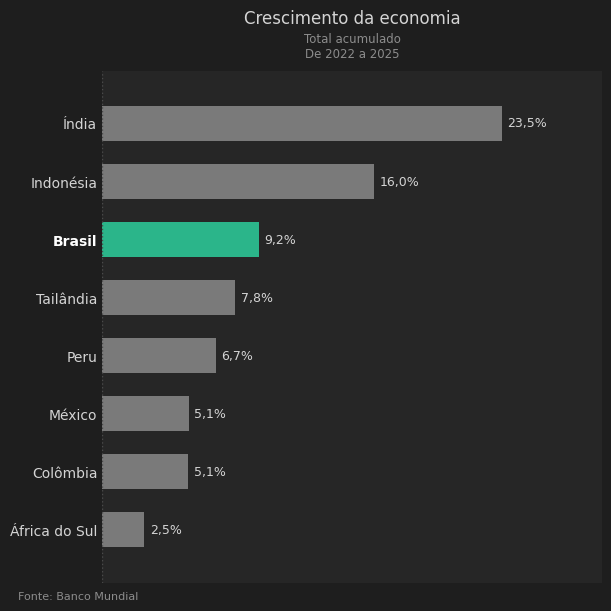

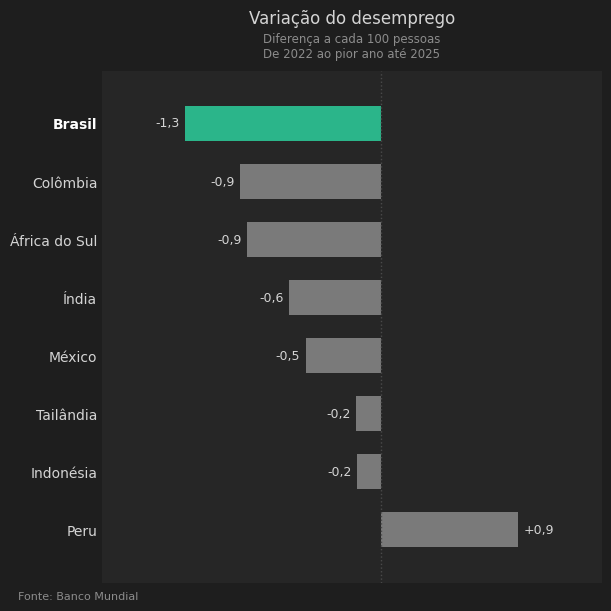

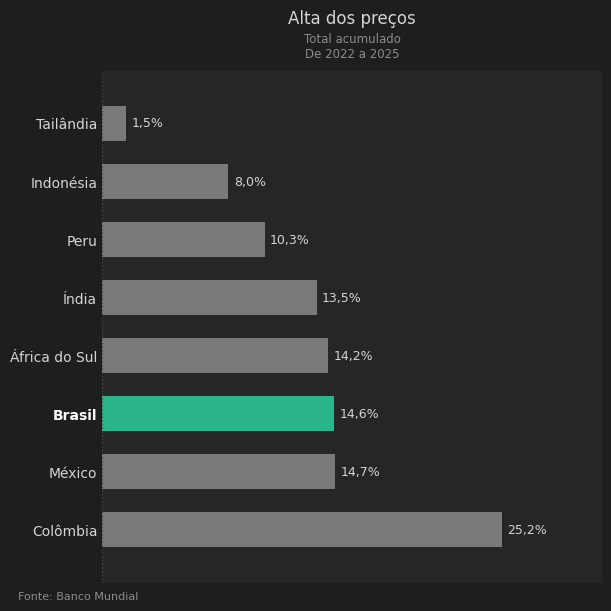

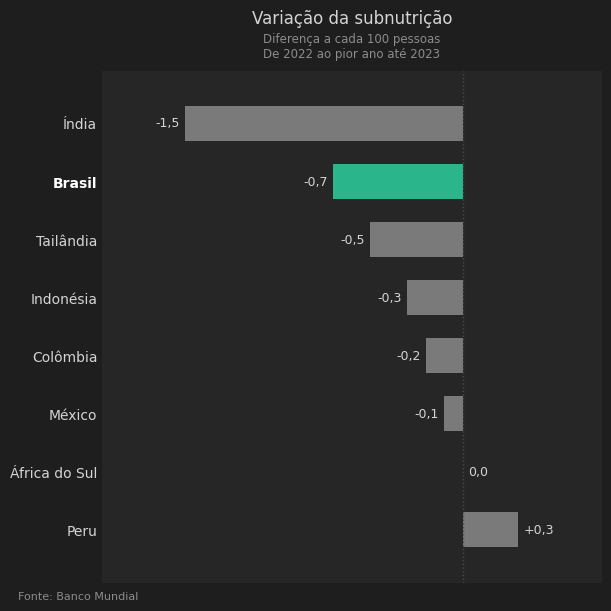

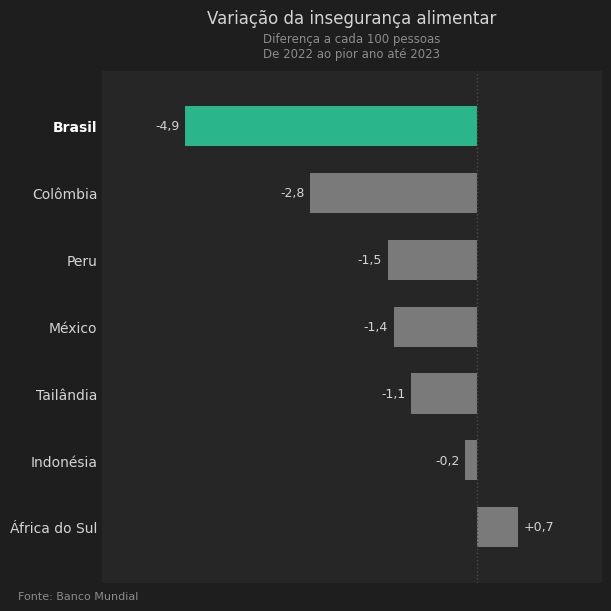

In [ ]:
# in this period most rates went down, so titles say "variação" and negative = improvement
TOTAL = f'Total acumulado\nDe {base_year} a {end_year}'
per_100 = lambda name: f'Diferença a cada 100 pessoas\nDe {base_year} ao pior ano até {last_year[name]}'

charts = [
    ('gdp_cumulative', 'Crescimento da economia', TOTAL, '{:.1f}%', True),
    ('unemployment_diff', 'Variação do desemprego', per_100('unemployment'), '{:+.1f}', False),
    ('inflation_cumulative', 'Alta dos preços', TOTAL, '{:.1f}%', False),
    ('undernourishment_diff', 'Variação da subnutrição', per_100('undernourishment'), '{:+.1f}', False),
    ('food_insecurity_diff', 'Variação da insegurança alimentar', per_100('food_insecurity'), '{:+.1f}', False),
]

# one square chart per indicator
ranking_figs_2 = {}
for column, *args in charts:
    fig, ax = plt.subplots(figsize=(6, 6), layout='constrained')
    draw_bars(ax, column, *args)
    fig.supxlabel(SOURCE, x=0.02, ha='left', fontsize=8, color=MUTED)
    ranking_figs_2[column] = fig
plt.show()